# Modelo **MA(q)**

Un modelo de media movil de orden **q**dice que el valor de la variable en el tiempo **t** depende de un termino de error actual y de los **shocks** de periodos anteriores 

$$X_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2} + \dots + \theta_q \varepsilon_{t-q}$$

**En palabras simples:** El modelo MA asume que un evento inesperado ocurrido ayer (un "shock") todavía tiene un eco en el valor de hoy.

Si o si se debe cumplir antes que:

- Los datos sean estacionarios

Lo que nos dice si es MA(q) o no es:

1. ACF: Si el ACF tiene barras que salen en los primeros *q* rezagos y luego cae es un MA

2. PACF: No se corta, sino que muestra un decaimiento gradual (exponencial o sinusoidal)

3. Estacionaria

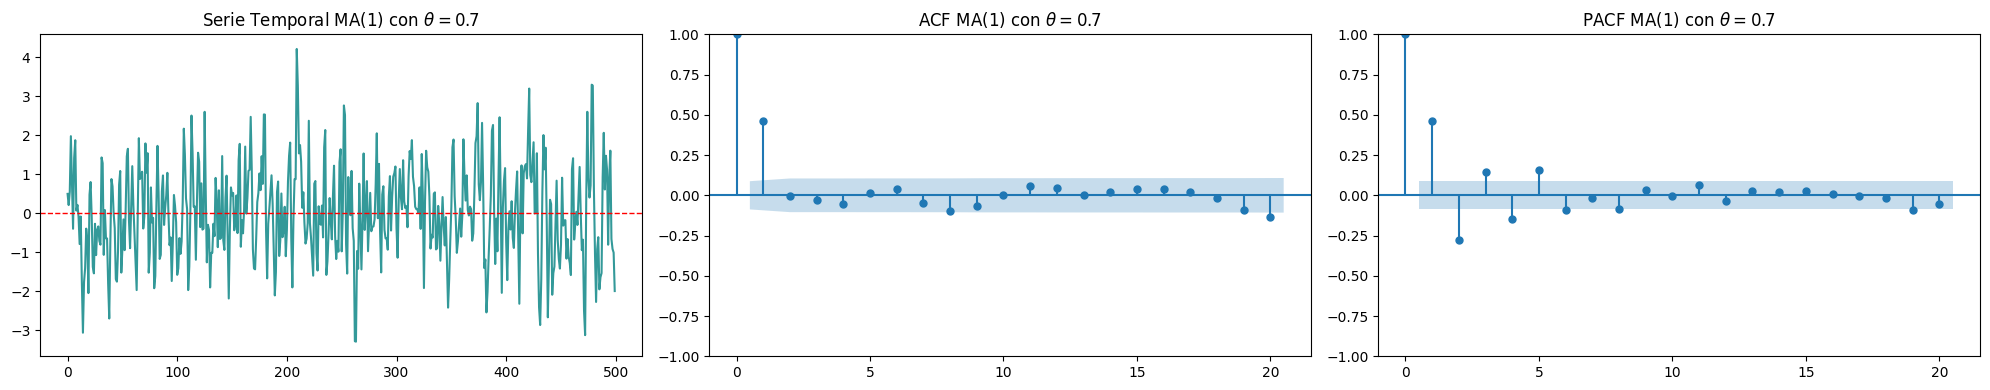

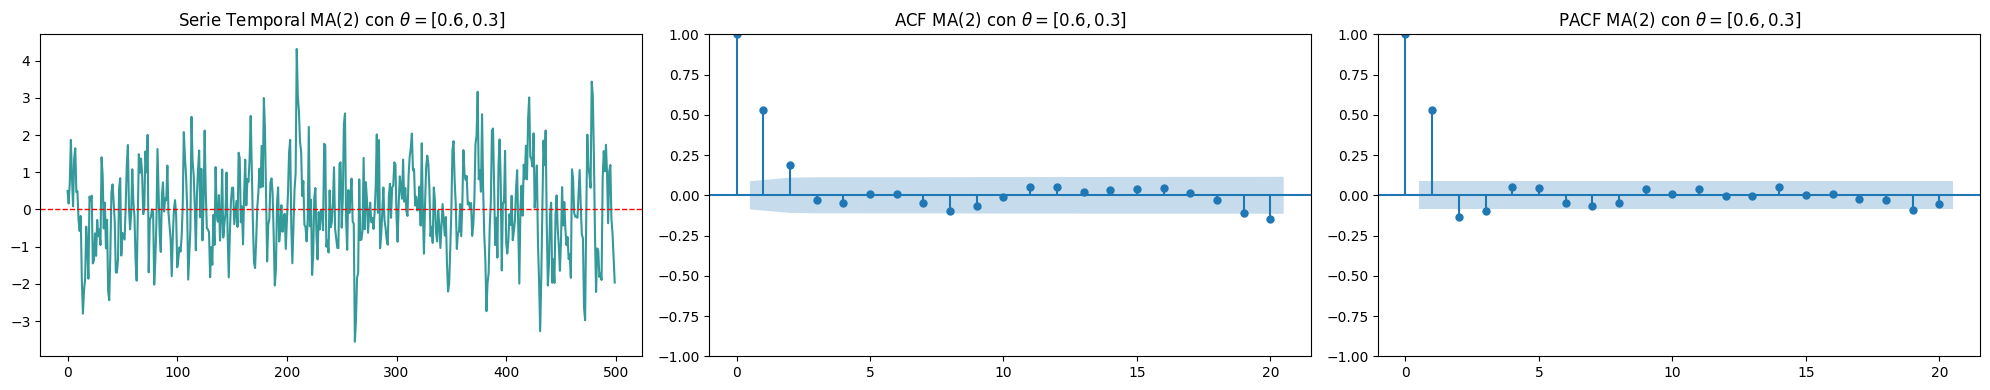

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def plot_proceso_ma(process, title):
    # Generar 500 muestras del proceso
    np.random.seed(42)
    data = process.generate_sample(nsample=500)
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 4))
    
    # Gráfico Temporal
    axes[0].plot(data, color='teal', alpha=0.8)
    axes[0].set_title(f'Serie Temporal {title}')
    axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
    
    # ACF
    plot_acf(data, ax=axes[1], lags=20, title=f'ACF {title}')
    
    # PACF
    plot_pacf(data, ax=axes[2], lags=20, title=f'PACF {title}', method='ywm')
    
    plt.tight_layout()
    plt.show()

# Nota: statsmodels usa el formato (1, theta_1, theta_2, ...) 
# para el polinomio de medias móviles.

# MA(1): y_t = epsilon_t + 0.7 * epsilon_{t-1}
ma1_params = np.array([1, 0.7])
ar1_params = np.array([1]) # Sin parte AR
process_ma1 = ArmaProcess(ar1_params, ma1_params)

# MA(2): y_t = epsilon_t + 0.6 * epsilon_{t-1} + 0.3 * epsilon_{t-2}
ma2_params = np.array([1, 0.6, 0.3])
process_ma2 = ArmaProcess(ar1_params, ma2_params)

# Ejecutar visualizaciones
plot_proceso_ma(process_ma1, "MA(1) con $\\theta=0.7$")
plot_proceso_ma(process_ma2, "MA(2) con $\\theta=[0.6, 0.3]$")

# Modelos **AR(p)**

Un modelo AR de orden **p**, el valor actual de la serie es una combinacion lineal de sus propios valores anteriores mas un error

$$X_t = c + \phi_1 X_{t-1} + \phi_2 X_{t-2} + \dots + \phi_p X_{t-p} + \varepsilon_t$$

**En palabras simples:** Si ayer hizo calor, hoy es probable que haga calor. El modelo AR asume que el pasado reciente es el mejor predictor del presente.

---

¿Como saber si debo aplicar un **AR**?

1. El ACF: La ACF no corta de golpe, sino que muestra un decaimiento gradual (muere lentamenta hacia 0)

2. El PACF: Tiene valores significativos en los rezagos **p** y luego cae a 0 abruptamente



<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:42: SyntaxWarning: invalid escape sequence '\p'
<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:42: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_4306/5136588.py:41: SyntaxWarning: invalid escape sequence '\p'
  plot_proceso_ar(process_ar1, "AR(1) con $\phi=0.7$")
/tmp/ipykernel_4306/5136588.py:42: SyntaxWarning: invalid escape sequence '\p'
  plot_proceso_ar(process_ar2, "AR(2) con $\phi=[0.5, 0.25]$")


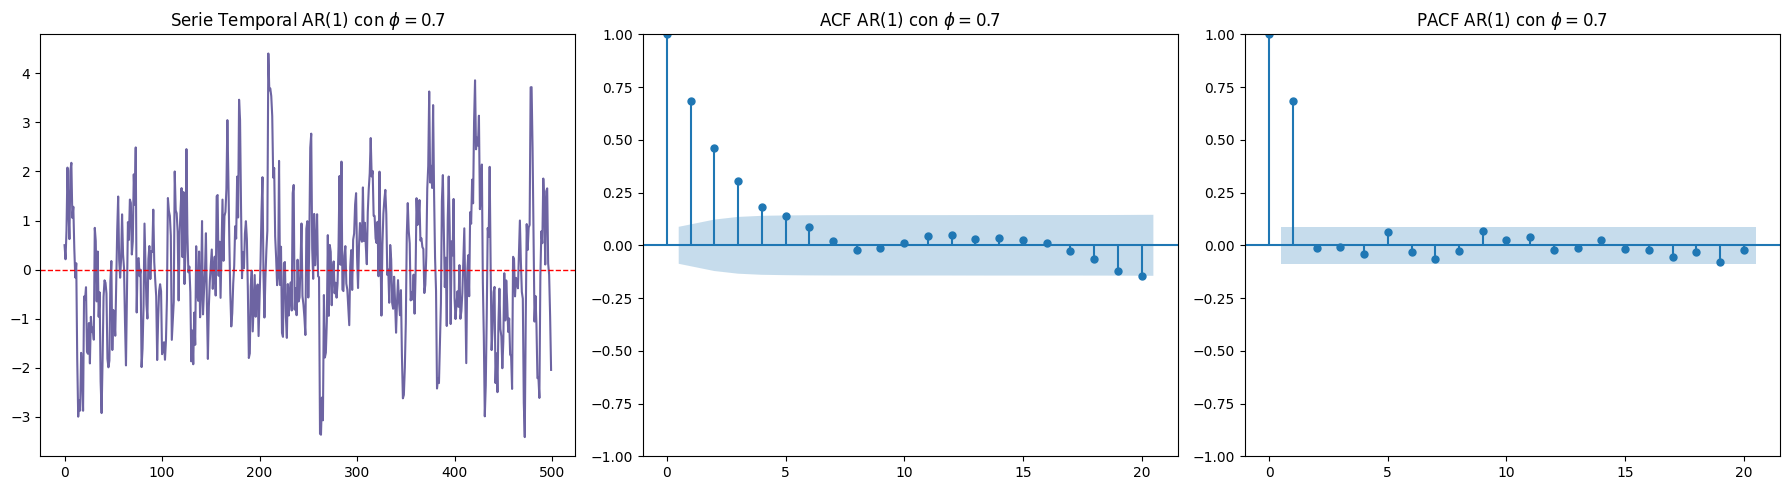

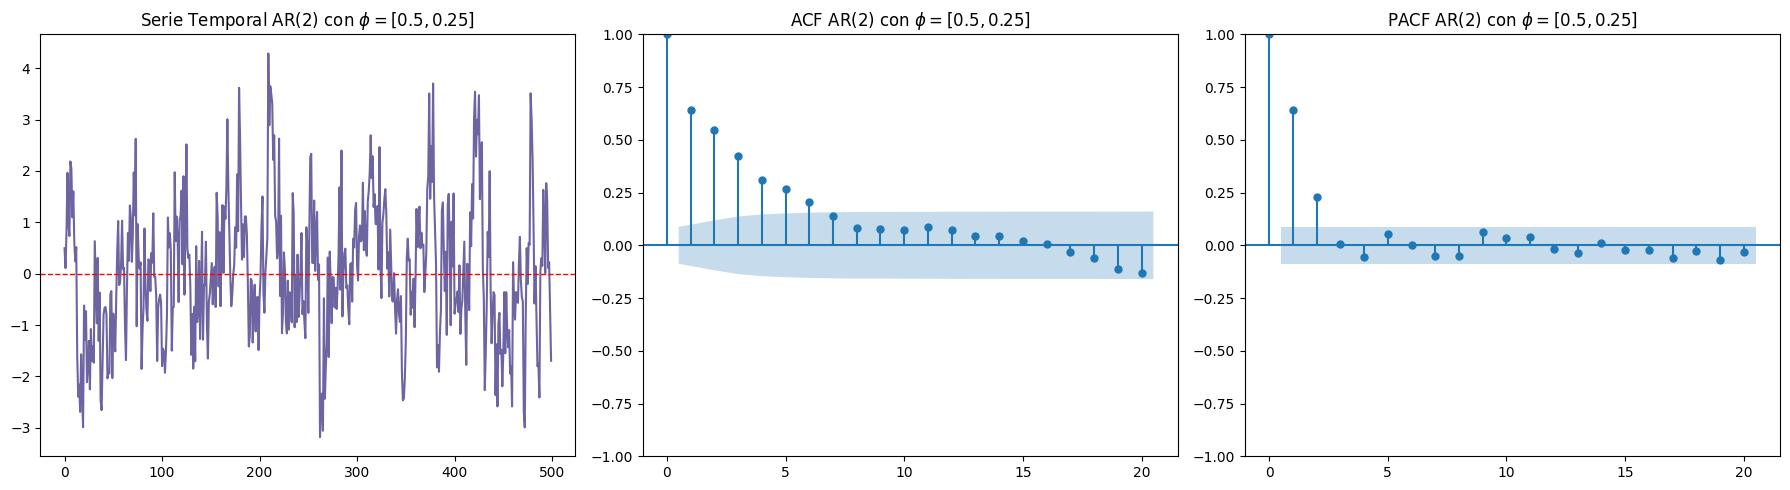

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def plot_proceso_ar(process, title):
    # Generar 500 muestras
    np.random.seed(42)
    data = process.generate_sample(nsample=500)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Gráfico Temporal
    axes[0].plot(data, color='darkslateblue', alpha=0.8)
    axes[0].set_title(f'Serie Temporal {title}')
    axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
    
    # ACF
    plot_acf(data, ax=axes[1], lags=20, title=f'ACF {title}')
    
    # PACF
    plot_pacf(data, ax=axes[2], lags=20, title=f'PACF {title}', method='ywm')
    
    plt.tight_layout()
    plt.show()

# Nota: statsmodels usa el formato (1, theta_1, theta_2, ...) 
# para el polinomio de medias móviles.

# AR(1): y_t = 0.7 * y_{t-1} + epsilon_t
ar1_params = np.array([1, -0.7])
ma_params = np.array([1]) # Sin parte MA
process_ar1 = ArmaProcess(ar1_params, ma_params)

# AR(2): y_t = 0.5 * y_{t-1} + 0.25 * y_{t-2} + epsilon_t
ar2_params = np.array([1, -0.5, -0.25])
process_ar2 = ArmaProcess(ar2_params, ma_params)

# Ejecutar visualizaciones
plot_proceso_ar(process_ar1, "AR(1) con $\phi=0.7$")
plot_proceso_ar(process_ar2, "AR(2) con $\phi=[0.5, 0.25]$")

# Modelo **ARMA(p,q)**

$$Yt=c+ϕ1Yt−1+...+ϕpYt−p+εt+θ1εt−1+...+θqεt−q$$

Para que un proceso ARMA(p,q) sea válido:

1. Estacionariedad: Raíces de ϕ(z)=0 fuera del círculo unitario
2. Invertibilidad: Raíces de θ(z)=0 fuera del círculo unitario
3. Parsimonia: Priorizar un modelo sencillo, utilizando la menor cantidad de parámetros necesaria para explicar adecuadamente los datos.

¿Como identifico un **ARMA(p,q)**?

| Modelo | ACF (Autocorrelación) | PACF (Autocorrelación Parcial) |
| :--- | :--- | :--- |
| **AR(p)** | Decae gradualmente (exponencial o sinusoidal) | **Corte abrupto** en el rezago $p$ |
| **MA(q)** | **Corte abrupto** en el rezago $q$ | Decae gradualmente |
| **ARMA(p,q)** | Decae gradualmente | Decae gradualmente |

Cuando esto sucede es mucha mas dificil identidicar **p y q** por lo que se recomienda aplicar criterios de Informacion como loa **AIC & BIC**


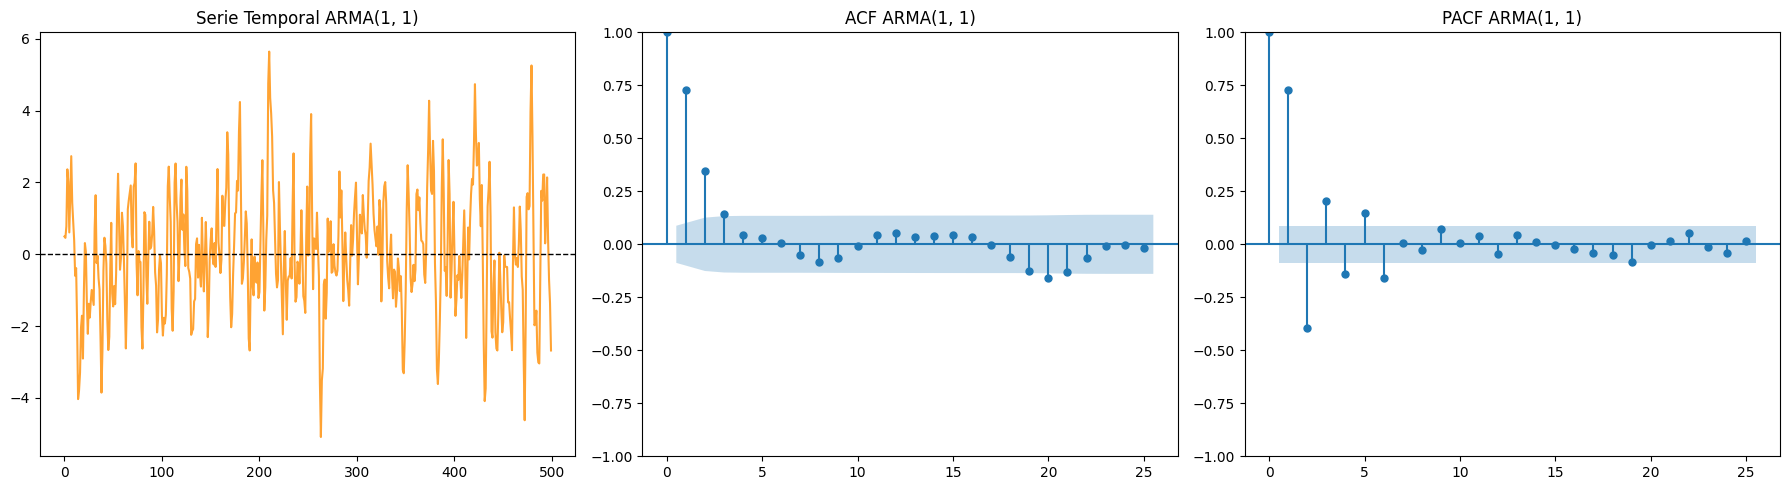

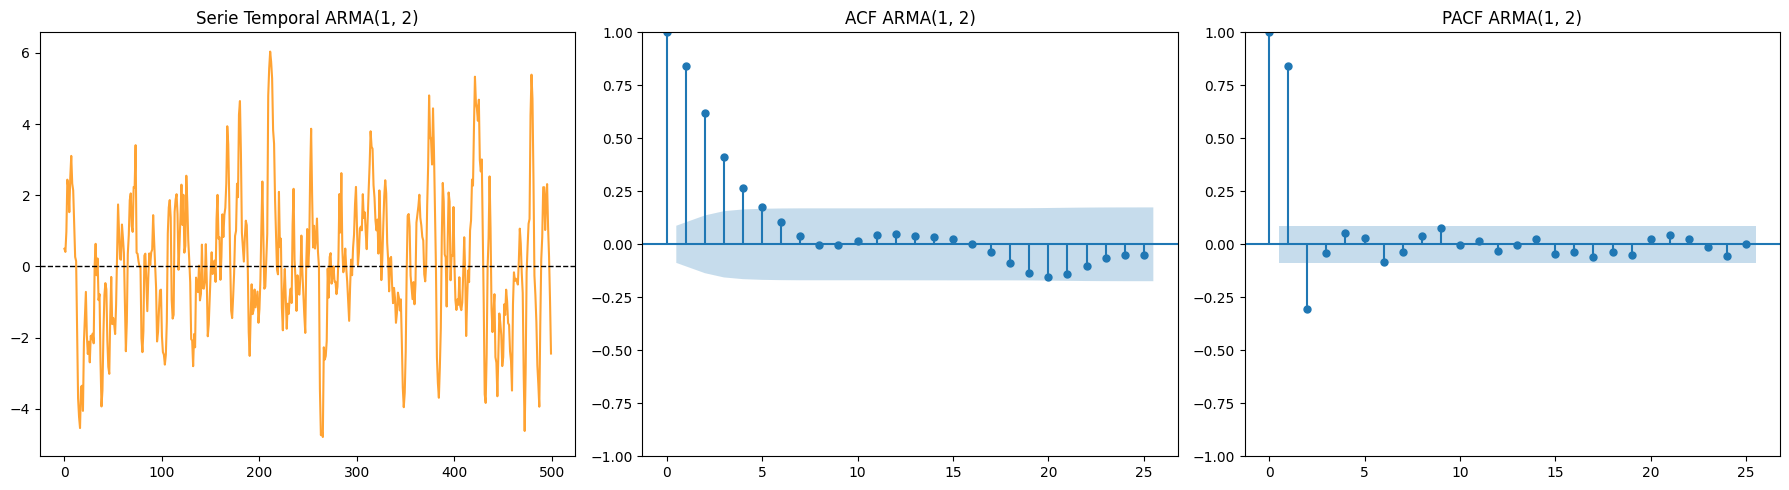

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def plot_proceso_arma(process, title):
    # Generar 500 muestras del proceso
    np.random.seed(42)
    data = process.generate_sample(nsample=500)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Gráfico Temporal
    axes[0].plot(data, color='darkorange', alpha=0.8)
    axes[0].set_title(f'Serie Temporal {title}')
    axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
    
    # ACF
    plot_acf(data, ax=axes[1], lags=25, title=f'ACF {title}')
    
    # PACF
    plot_pacf(data, ax=axes[2], lags=25, title=f'PACF {title}', method='ywm')
    
    plt.tight_layout()
    plt.show()

# ARMA(1, 1): y_t = 0.5*y_{t-1} + epsilon_t + 0.7*epsilon_{t-1}
ar11 = np.array([1, -0.5])  # AR: (1 - 0.5L)
ma11 = np.array([1, 0.7])   # MA: (1 + 0.7L)
process_arma11 = ArmaProcess(ar11, ma11)

# ARMA(1, 2): y_t = 0.7*y_{t-1} + epsilon_t + 0.4*epsilon_{t-1} + 0.2*epsilon_{t-2}
ar12 = np.array([1, -0.7])  # AR: (1 - 0.7L)
ma12 = np.array([1, 0.4, 0.2]) # MA: (1 + 0.4L + 0.2L^2)
process_arma12 = ArmaProcess(ar12, ma12)

# Ejecutar visualizaciones
plot_proceso_arma(process_arma11, "ARMA(1, 1)")
plot_proceso_arma(process_arma12, "ARMA(1, 2)")

# Modelo **ARIMA(p,q,d)**

- ARIMA: AutoRegressive Integrated Moving Average

Combinan tres componentes fundamentales:
1. AR: Autoregresivo (dependencia del pasado)
2. I: Integración (diferenciación para estacionariedad)
3. MA: Medias Móviles (dependencia de errores pasados)

El **ARMA** es así:

$$Yt=c+ϕ1Yt−1+...+ϕpYt−p+εt+θ1εt−1+...+θqεt−q$$

Pero si diferenciamos nos queda un **ARIMA(p,d,q)**

$$y′t=c+ϕ1y′t−1+⋯+ϕpy′t−p+θ1εt−1+⋯+θqεt−q+εtϕ(B)(1−B)dYt=c+θ(B)εt$$

¿Como se si mi modelo ARIMA es valido?

1. Estacionariedad: Raíces de ϕ(z)=0 fuera del círculo unitario
2. Invertibilidad: Raíces de θ(z)=0 fuera del círculo unitario
3. Parsimonia: Priorizar un modelo sencillo, utilizando la menor cantidad de parámetros necesaria para explicar adecuadamente los dato

## Modelos Especiales (ARIMA)

| Modelo | Nombre | Ecuación |
| :--- | :--- | :--- |
| **ARIMA(0,0,0)** sin constante | Ruido blanco | $Y_t = \varepsilon_t$ |
| **ARIMA(0,1,0)** sin constante | Camino aleatorio | $Y_t = Y_{t-1} + \varepsilon_t$ |
| **ARIMA(0,1,0)** con constante | Camino aleatorio con deriva | $Y_t = c + Y_{t-1} + \varepsilon_t$ |
| **ARIMA(0,0,1)** | Media móvil | $Y_t = \varepsilon_t + \theta\varepsilon_{t-1}$ |
| **ARIMA(1,0,0)** | Autoregresivo | $Y_t = \phi Y_{t-1} + \varepsilon_t$ |
| **ARIMA(0,1,1)** | Suavizamiento exponencial simple | $\Delta Y_t = \varepsilon_t + \theta\varepsilon_{t-1}$ |
| **ARIMA(1,1,0)** | Crecimiento autoregresivo | $\Delta Y_t = \phi \Delta Y_{t-1} + \varepsilon_t$ |

## Algoritmo de Estimacion del **ARIMA(p,d,q)** Box-Jenkins

1. Grafique los datos e identifique cualquier observación inusual (valores atípicos).
2. Si es necesario, transforme los datos (utilizando una transformación de Box-Cox) para estabilizar la varianza.
3. Si los datos no son estacionarios, aplique primeras diferencias hasta que la serie sea estacionaria. Importante verificar prueba de Dickey-Fuller aumentada y Kwiatkowski-Phillips-Schmidt-Shin (KPSS). Usualmente 0≥d≥2
4. Examine el ACF y PACF: ¿Es adecuado un modelo ARIMA(p,d,0) o un ARIMA(0,d,q)?
5. Pruebe los modelos seleccionados y utilice el Criterio de Información Akaike corregido para muestras pequeñas (AICc) para buscar un modelo mejor.
6. Verifique los residuos de su modelo elegido mediante el gráfico del ACF de los residuos y realizando una prueba Ljung-Box. Si no se comportan como ruido blanco, intente con un modelo modificado.
7. Una vez que los residuos parezcan ruido blanco, calcule los pronósticos.

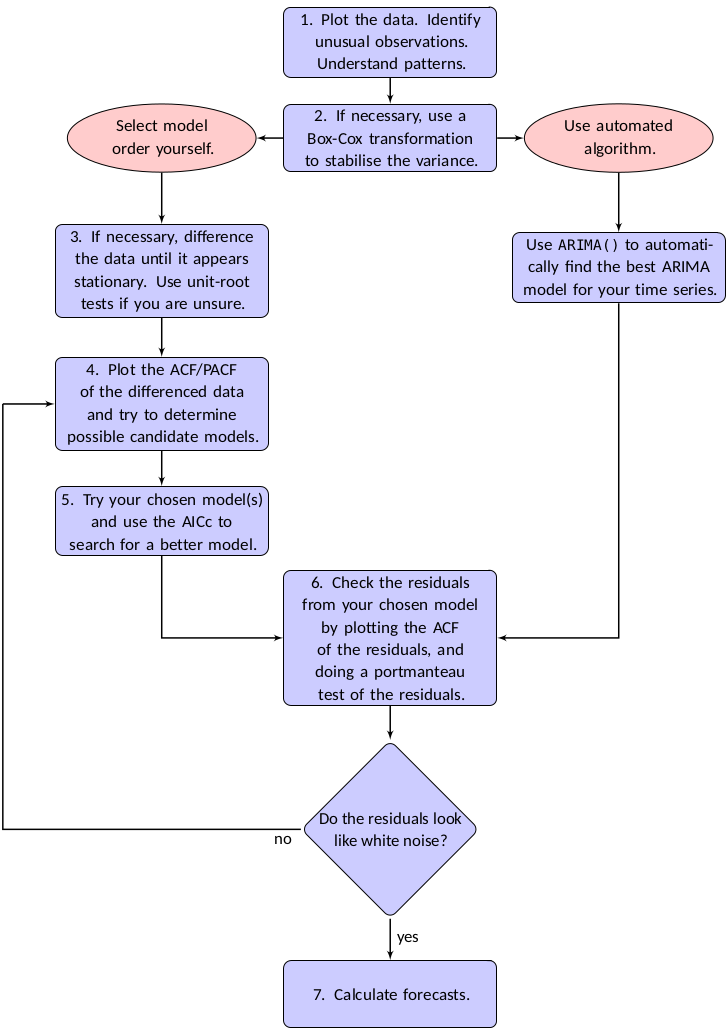

---

## Algoritmo Auto-ARIMA(p, d, q)

Como bien pudiste observar, el proceso de seleccionar y estimar un modelo ARIMA(p, d, q) es iterativo buscando finalmente un modelo con menor Criterio de Información Akaike (AICc) tal que sus residuos sean se comporten como ruido blanco.

$$εt∼IIDN(0,σ2)$$

1. Los valores de p y q se eligen minimizando el AICc después de diferenciar los datos d veces. En lugar de considerar cada combinación posible de p y q, el algoritmo utiliza una búsqueda por pasos para recorrer el espacio de modelos.

2. **Se ajustan cuatro modelos iniciales:**

1. ARIMA(0,d,0)
2. ARIMA(2,d,2)
3. ARIMA(1,d,0)
4. ARIMA(0,d,1)

3. Se incluye una constante (deriva) a menos que d=2. Si d≤1 ,también se ajusta un modelo adicional:

- ARIMA(0,d,0) sin constante.

4. El mejor modelo (con el valor AICc más pequeño) ajustado en el paso (2) se establece como el “modelo actual”.

5. El mejor modelo considerado hasta el momento (ya sea el modelo actual o una de estas variaciones) se convierte en el nuevo modelo actual.

6. Repetir el paso 4 hasta que no se pueda encontrar un AICc más bajo

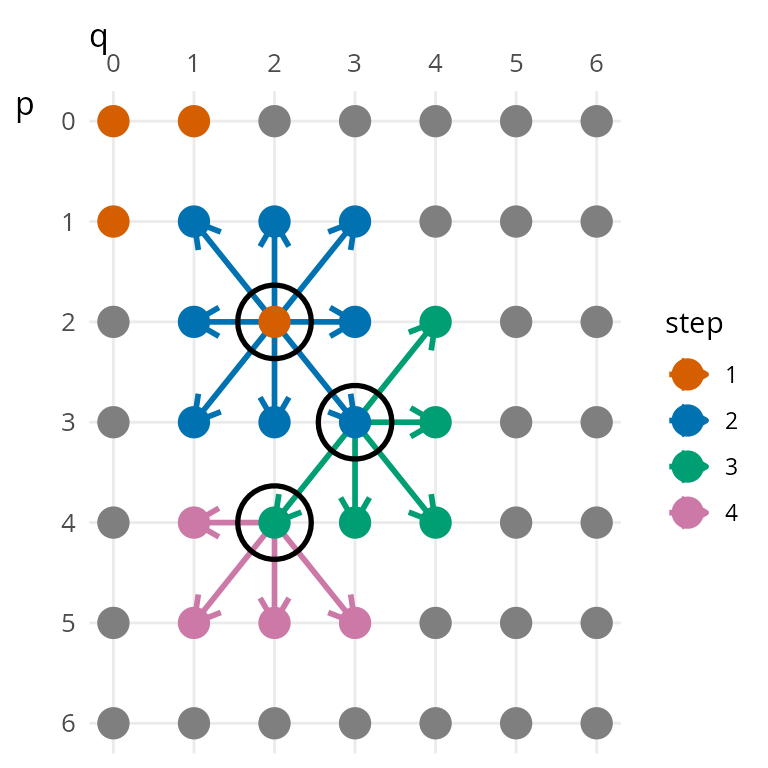

## Transformacion Box-Cox

Es un metodo estadistico que se usa para modificar la distribucion de los datos y que se acerquen mas a una distribucion normal y para estabilizar la varianza

La transformación depende de un parámetro llamado λ
 (lambda). Para una variable yt
​ (que debe ser estrictamente positiva), la transformación se define como:

**Nota: La transformación logarítmica (λ=0) es la más frecuente en economía porque permite interpretar los cambios en la serie como tasas de crecimiento porcentual.**

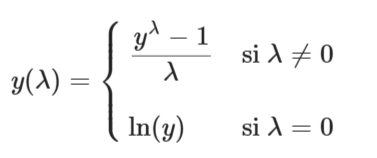

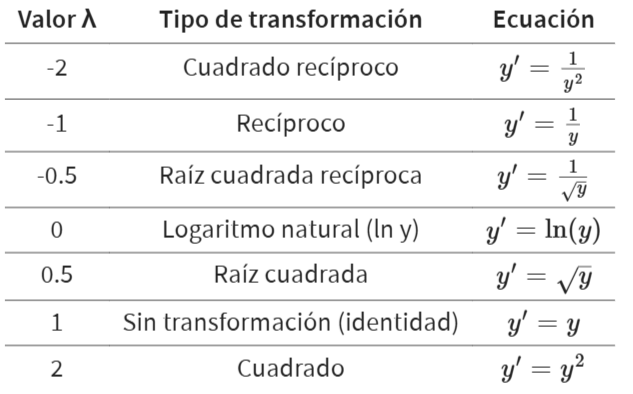





# Ejercicio

Usando los datos del Banco Mundial, estime un modelo ARIMA válido acorde a la teoría entre 1960-2024. Finalmente, realice el pronostico del PIB de Colombia para los próximos 5 años.

In [19]:
import wbgapi as wb

# Ejemplo: Descargar el PIB de Colombia de los últimos 5 años
data = wb.data.DataFrame('NY.GDP.MKTP.CD', 'COL', time=range(1960, 2024))
data

,YR1960,YR1961,YR1962,YR1963,YR1964,YR1965,YR1966,YR1967,YR1968,YR1969,...,YR2014,YR2015,YR2016,YR2017,YR2018,YR2019,YR2020,YR2021,YR2022,YR2023
economy,,,,,,,,,,,,,,,,,,,,,
COL,4.031153e+09,4.540448e+09,4.955544e+09,4.836167e+09,5.973367e+09,5.760762e+09,5.428519e+09,5.825170e+09,5.960213e+09,6.450175e+09,...,3.812409e+11,2.934924e+11,2.827201e+11,3.118669e+11,3.341982e+11,3.230317e+11,2.703483e+11,3.185246e+11,3.456325e+11,3.662918e+11


In [20]:
import pandas as pd

# 1. Si 'economy' no aparece, reseteamos el índice por si acaso el país está ahí
df_temp = data.reset_index()

# 2. Identificamos automáticamente la primera columna (que suele ser el país/id)
columna_id = df_temp.columns[0] 

# 3. Aplicamos el melt usando ese nombre detectado
df_clean = df_temp.melt(id_vars=[columna_id], var_name='Year', value_name='Valor')

# 4. Limpiamos el año
df_clean['Year'] = df_clean['Year'].str.extract('(\d+)').astype(int) # Más seguro que .replace

<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_4306/1703404603.py:13: SyntaxWarning: invalid escape sequence '\d'
  df_clean['Year'] = df_clean['Year'].str.extract('(\d+)').astype(int) # Más seguro que .replace


In [21]:
# Convertir correctamente el año
df_clean['Year'] = pd.to_datetime(df_clean['Year'], format='%Y')

# Asegúrate de que el índice sea el año para que las funciones de statsmodels funcionen
df_clean.set_index('Year', inplace=True)

In [27]:
df_clean

,economy,Valor
Year,,
1960-01-01,COL,4.031153e+09
1961-01-01,COL,4.540448e+09
1962-01-01,COL,4.955544e+09
1963-01-01,COL,4.836167e+09
1964-01-01,COL,5.973367e+09
...,...,...
2019-01-01,COL,3.230317e+11
2020-01-01,COL,2.703483e+11
2021-01-01,COL,3.185246e+11


In [28]:
df_clean = df_clean.drop(columns="economy")

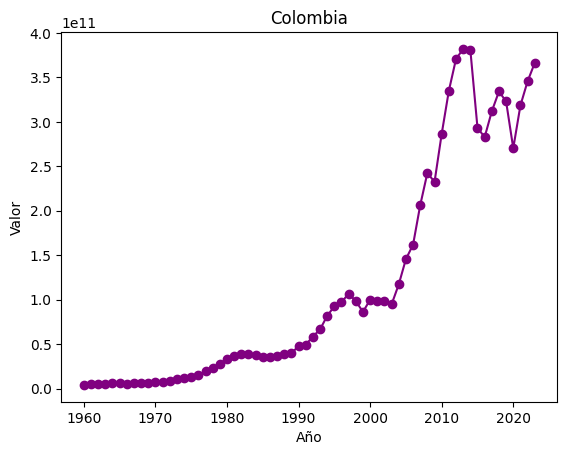

In [29]:
import matplotlib.pyplot as plt

plt.plot(df_clean["Valor"],marker="o",color="purple")
plt.title("Colombia")
plt.xlabel("Año")
plt.ylabel("Valor")
plt.show()

## Verificamos Estacionariedad

Text(0.5, 1.0, 'ACF')

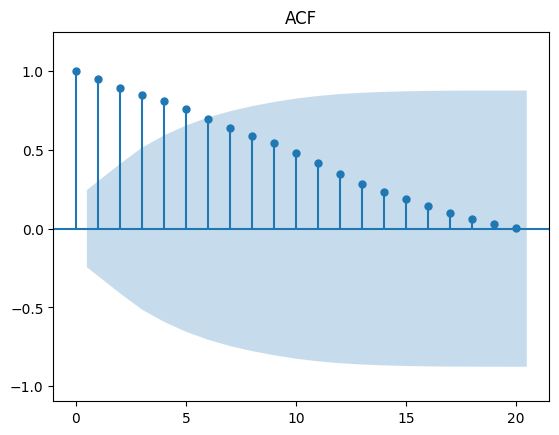

In [30]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df_clean,lags=20,auto_ylims=True)
plt.title("ACF")

Text(0.5, 1.0, 'PACF')

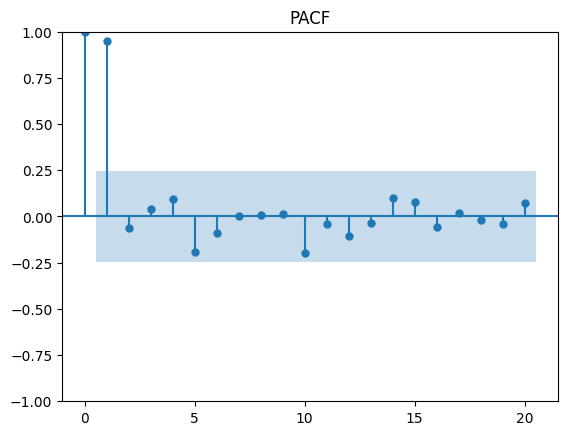

In [31]:
plot_pacf(df_clean,lags=20)
plt.title("PACF")

In [34]:
from statsmodels.stats.diagnostic import acorr_ljungbox

test = acorr_ljungbox(df_clean,lags=20,return_df=True)
round(test,4),round(test.mean()),4

(     lb_stat  lb_pvalue
 1    60.2868        0.0
 2   114.6230        0.0
 3   164.0666        0.0
 4   210.1880        0.0
 5   251.1927        0.0
 6   286.4492        0.0
 7   316.6504        0.0
 8   342.8997        0.0
 9   365.6825        0.0
 10  383.7245        0.0
 11  397.3718        0.0
 12  407.0372        0.0
 13  413.6930        0.0
 14  418.2162        0.0
 15  421.2962        0.0
 16  423.0811        0.0
 17  423.9853        0.0
 18  424.3609        0.0
 19  424.4438        0.0
 20  424.4446        0.0,
 lb_stat      334.0
 lb_pvalue      0.0
 dtype: float64,
 4)

In [35]:
from statsmodels.tsa.stattools import adfuller, kpss

adf = adfuller(df_clean)
kpss = kpss(df_clean,regression="c")

tests = pd.DataFrame({
    "Test":["ADF","kpss"],
    "Estadisticos":[adf[0],kpss[0]],
    "p_values":[adf[1],kpss[2]],
    "Estacionarios":["Si" if adf[1] < 0.05 else "No","No" if kpss[1]<0.05 else "Si"]
})

tests

/tmp/ipykernel_4306/2052761394.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss = kpss(df_clean,regression="c")


,Test,Estadisticos,p_values,Estacionarios
0,ADF,2.771744,1.0,No
1,kpss,0.998433,5.0,No


Como no son estacionarios, integramos la serie una vez e incluso al tener mucha varianza podriamos aplicar una transformacion **box-cox** al ser una serie economica aplicamos la 0 o logaritmo

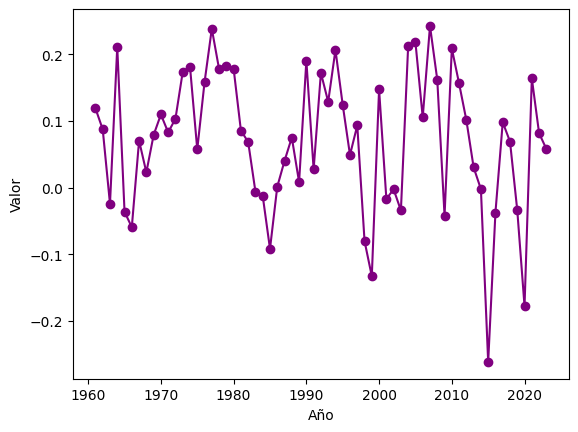

In [36]:
import numpy as np

pib_diff_1 = df_clean.diff().dropna()
pib_log_1 = np.log(df_clean)
pib_crecimiento = pib_log_1.diff().dropna()

plt.plot(pib_crecimiento,marker="o",color="purple")
plt.xlabel("Año")
plt.ylabel("Valor")
plt.show()


## Verificamos estacionariedad con diferenciaciion

Text(0.5, 1.0, 'ACF Con Diff')

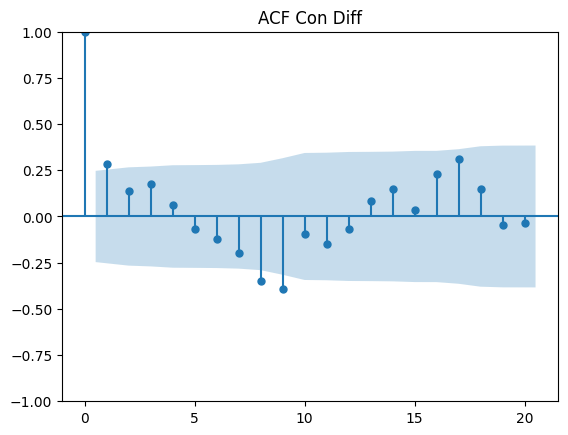

In [37]:
plot_acf(pib_crecimiento,lags=20)
plt.title("ACF Con Diff")

Text(0.5, 1.0, 'PACF con diff')

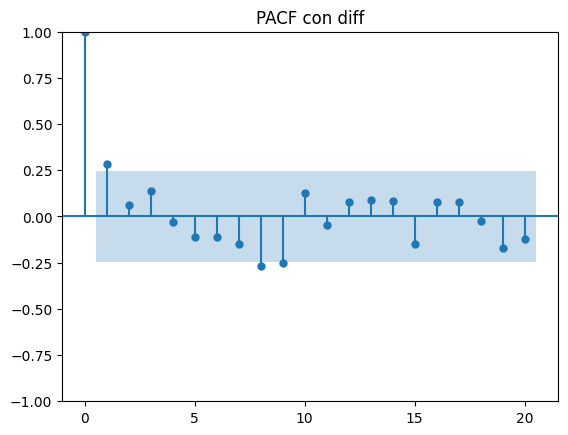

In [39]:
plot_pacf(pib_crecimiento,lags=20)
plt.title("PACF con diff")

In [42]:
tests_ljung = acorr_ljungbox(pib_crecimiento)
round(tests_ljung,4)

,lb_stat,lb_pvalue
1,5.2887,0.0215
2,6.5385,0.0380
3,8.7002,0.0336
4,8.9525,0.0623
5,9.2809,0.0984
6,10.3292,0.1115
7,13.1523,0.0685
8,22.3625,0.0043
9,33.9541,0.0001
10,34.6235,0.0001


In [43]:
from statsmodels.tsa.stattools import adfuller, kpss

adf = adfuller(pib_crecimiento)
kpss = kpss(pib_crecimiento,regression="c")

tests = pd.DataFrame({
    "Test":["ADF","kpss"],
    "Estadisticos":[adf[0],kpss[0]],
    "p_values":[adf[1],kpss[2]],
    "Estacionarios":["Si" if adf[1] < 0.05 else "No","No" if kpss[1]<0.05 else "Si"]
})

tests

/tmp/ipykernel_4306/1922871662.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss = kpss(pib_crecimiento,regression="c")


,Test,Estadisticos,p_values,Estacionarios
0,ADF,-5.799793,4.659863e-07,Si
1,kpss,0.146220,3.000000e+00,Si


Ahora que la seire si es estacionaria consideramos aplicar un ARIMA

In [44]:
from statsmodels.tsa.arima.model import ARIMA
#Probemos con un ARIMA(1,1,1)

arima111 = ARIMA(pib_crecimiento, order=(1,0,1),trend="n").fit()
arima111.summary()

/mnt/c/Users/Pc/Documents/series-de-tiempo-utb/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/mnt/c/Users/Pc/Documents/series-de-tiempo-utb/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/mnt/c/Users/Pc/Documents/series-de-tiempo-utb/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Valor   No. Observations:                   63
Model:                 ARIMA(1, 0, 1)   Log Likelihood                  52.573
Date:                Mon, 02 Mar 2026   AIC                            -99.146
Time:                        08:16:52   BIC                            -92.717
Sample:                    01-01-1961   HQIC                           -96.618
                         - 01-01-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8666      0.102      8.519      0.000       0.667       1.066
ma.L1         -0.5352      0.153     -3.507      0.000      -0.834      -0.236
sigma2         0.0109      0.002      5.407      0.000       0.007       0.015
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):                 1.34
Prob(Q):                              0.82   Prob(JB):                         0.51
Heteroskedasticity (H):               2.38   Skew:                            -0.34
Prob(H) (two-sided):                  0.05   Kurtosis:                         3.22
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [45]:
from pmdarima import auto_arima #Para hacer un auto arima que me calcula el mejor modelo

models = auto_arima(pib_crecimiento,
                    seasonal=False,
                    stepwise=True,
                    trace=True,
                    error_action="ignore",
                    suppress_warnings=True,
                    max_p=5,max_q=5,d=None,trend="n") #No diff

models.summary()

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-95.508, Time=0.22 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-79.573, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-96.161, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-90.520, Time=0.05 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-96.649, Time=0.05 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=-98.066, Time=0.14 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=-96.221, Time=0.09 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=-96.190, Time=0.08 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-97.191, Time=0.10 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=-94.273, Time=0.19 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=-98.066, Time=0.08 sec

Best model:  ARIMA(3,0,0)(0,0,0)[0] intercept
Total fit time: 1.137 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   63
Model:               SARIMAX(3, 0, 0)   Log Likelihood                  53.033
Date:                Mon, 02 Mar 2026   AIC                            -98.066
Time:                        08:19:00   BIC                            -89.494
Sample:                    01-01-1961   HQIC                           -94.695
                         - 01-01-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3580      0.138      2.595      0.009       0.088       0.628
ar.L2          0.1043      0.152      0.686      0.492      -0.194       0.402
ar.L3          0.2301      0.142      1.625      0.104      -0.047       0.508
sigma2         0.0108      0.002      5.370      0.000       0.007       0.015
===================================================================================
Ljung-Box (L1) (Q):                   0.22   Jarque-Bera (JB):                 1.78
Prob(Q):                              0.64   Prob(JB):                         0.41
Heteroskedasticity (H):               2.55   Skew:                            -0.39
Prob(H) (two-sided):                  0.04   Kurtosis:                         3.27
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Ahora que ya tenemos el mejor modelo, tenemos que verificar que los errores sean ruido blanco por los supuestos

In [53]:
mejormodelo = ARIMA(pib_crecimiento,order=(3,0,0),trend="n").fit()
mejormodelo.summary()

/mnt/c/Users/Pc/Documents/series-de-tiempo-utb/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/mnt/c/Users/Pc/Documents/series-de-tiempo-utb/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/mnt/c/Users/Pc/Documents/series-de-tiempo-utb/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Valor   No. Observations:                   63
Model:                 ARIMA(3, 0, 0)   Log Likelihood                  53.033
Date:                Mon, 02 Mar 2026   AIC                            -98.066
Time:                        08:23:49   BIC                            -89.494
Sample:                    01-01-1961   HQIC                           -94.695
                         - 01-01-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3580      0.138      2.595      0.009       0.088       0.628
ar.L2          0.1043      0.152      0.686      0.492      -0.194       0.402
ar.L3          0.2301      0.142      1.625      0.104      -0.047       0.508
sigma2         0.0108      0.002      5.370      0.000       0.007       0.015
===================================================================================
Ljung-Box (L1) (Q):                   0.22   Jarque-Bera (JB):                 1.78
Prob(Q):                              0.64   Prob(JB):                         0.41
Heteroskedasticity (H):               2.55   Skew:                            -0.39
Prob(H) (two-sided):                  0.04   Kurtosis:                         3.27
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [55]:
residuos = mejormodelo.resid
residuos_std = (residuos-residuos.mean())/residuos.std()

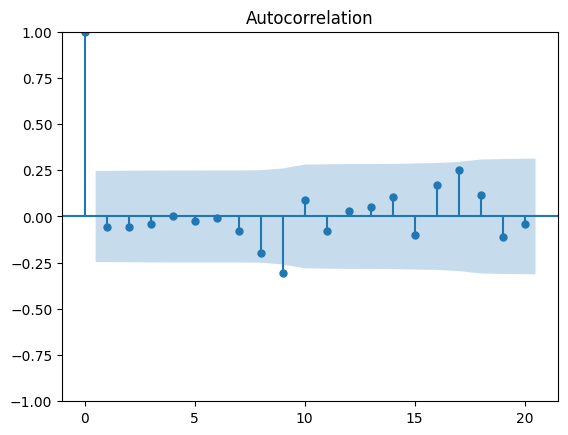

In [57]:
plot_acf(residuos,lags=20)
plt.show()

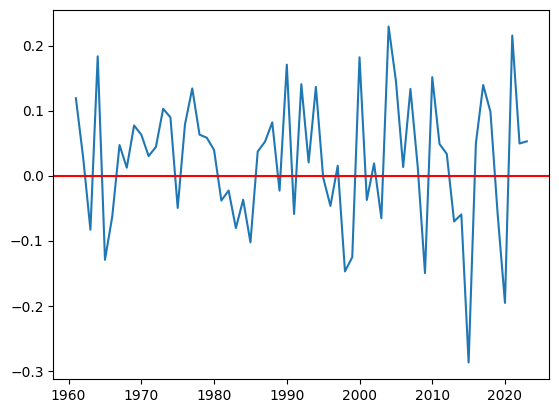

In [58]:
plt.plot(residuos)
plt.axhline(y=0,color="red")
plt.show()

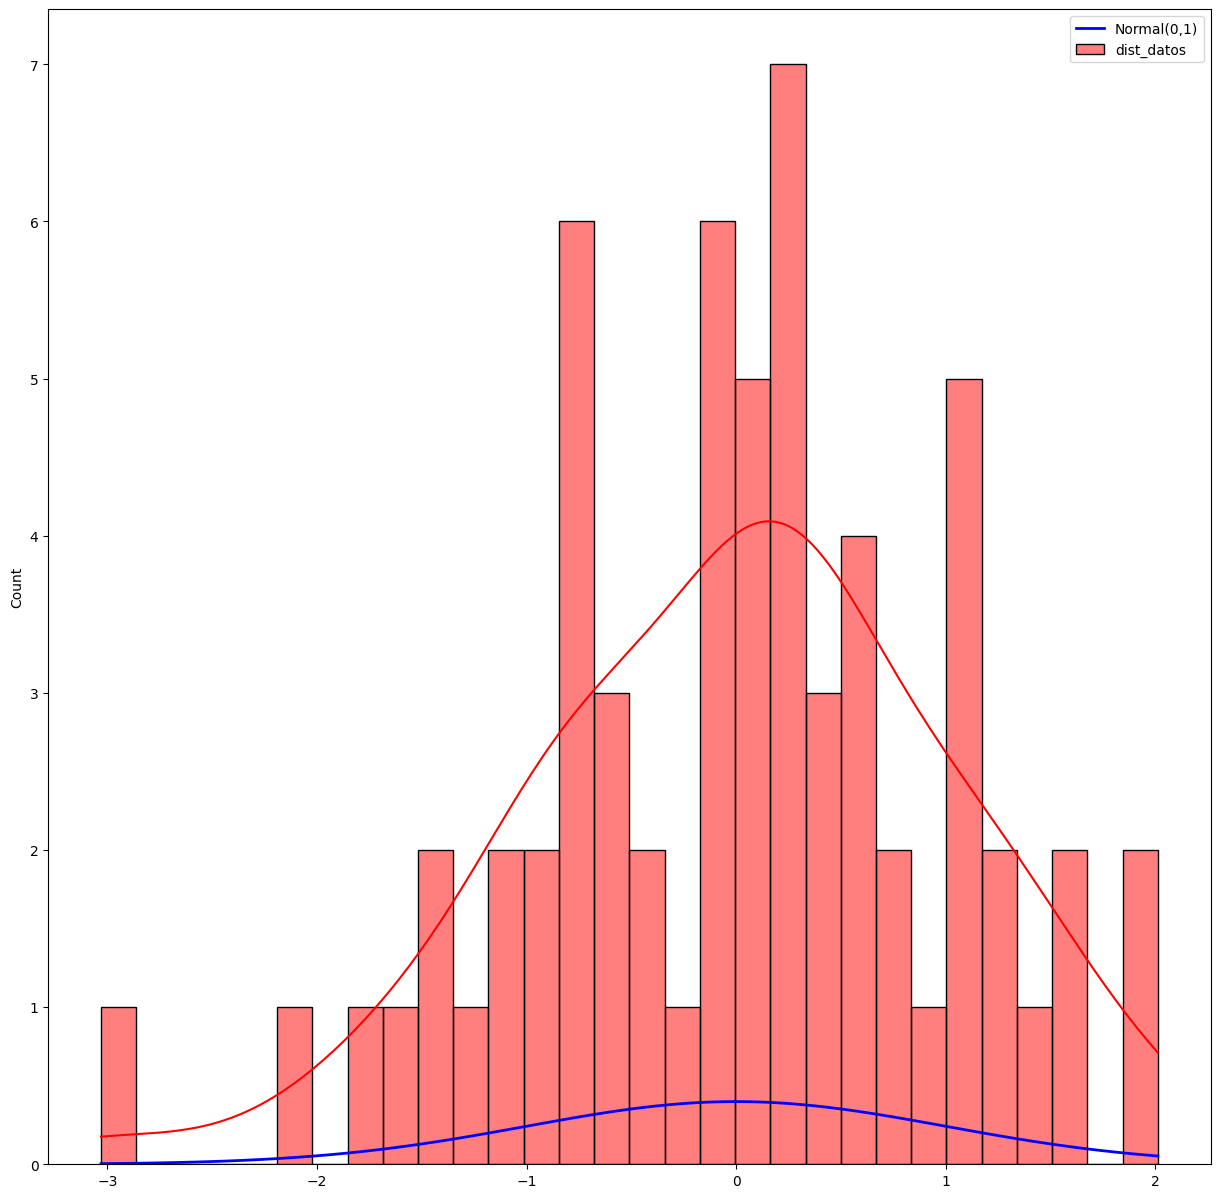

In [66]:
import seaborn as sns
from scipy import stats

plt.figure(figsize=(15,15))
x = np.linspace(residuos_std.min(), residuos_std.max(), 100)

sns.histplot(residuos_std,bins=30,kde=True,color="red",label="dist_datos")
plt.plot(x, stats.norm.pdf(x, 0, 1), color="blue", linewidth=2, label='Normal(0,1)')
plt.legend()
plt.show()

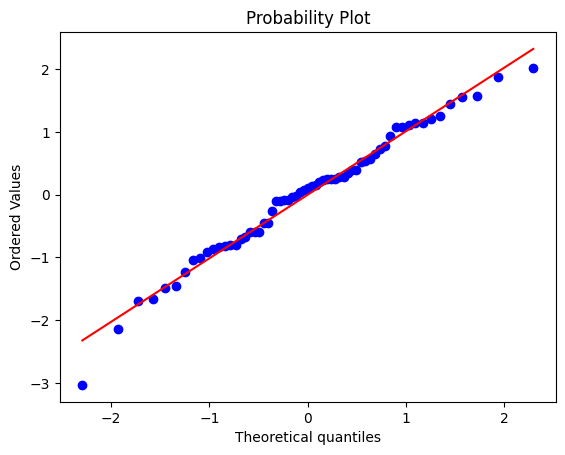

In [68]:
stats.probplot(residuos_std,dist="norm",plot=plt)
plt.show()

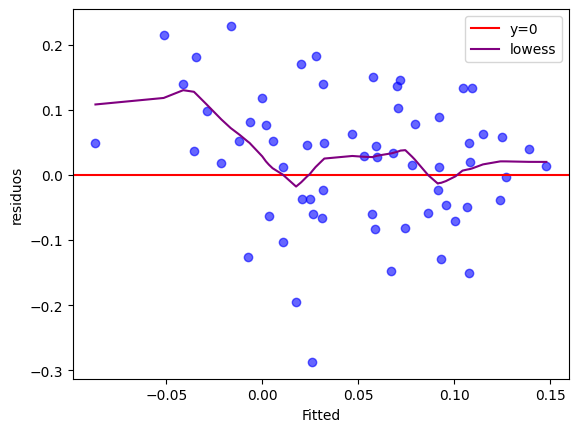

In [73]:
from statsmodels.nonparametric.smoothers_lowess import lowess

fitted_vals = mejormodelo.fittedvalues

plt.scatter(fitted_vals,residuos,alpha=0.6,color="blue")
plt.axhline(y=0,color="red",label="y=0")

lowes = lowess(residuos, fitted_vals, frac=0.3)
plt.plot(lowes[:,0],lowes[:,1],color="purple",label="lowess")

plt.xlabel("Fitted")
plt.ylabel("residuos")
plt.legend()
plt.show()

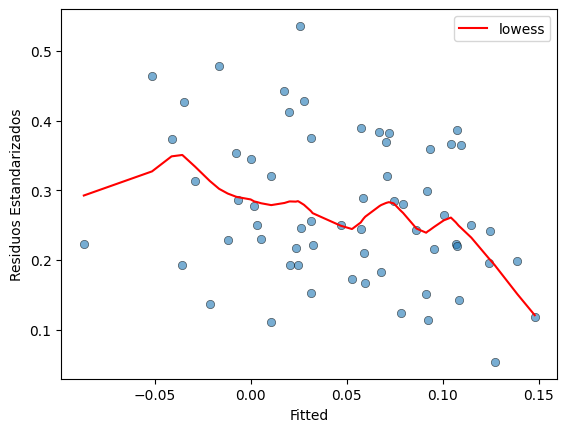

In [75]:
resid_abs = np.abs(residuos)
resid_sqrt = np.sqrt(resid_abs)

plt.scatter(fitted_vals, resid_sqrt, alpha=0.6, edgecolors='k', linewidth=0.5)
lowes2 = lowess(resid_sqrt,fitted_vals,frac=0.3)
plt.plot(lowes2[:,0],lowes2[:,1],color="red",label="lowess")
plt.legend()
plt.xlabel("Fitted")
plt.ylabel("Residuos Estandarizados")
plt.show()

## Pronostico de este mejor modelo

In [78]:
# Pronostico de los proximos 5 años
t_pronostico = 5
ultimo_anio  = pib_crecimiento.index[-1]
anio_pronostico = range(ultimo_anio + 1, ultimo_anio + 1 + t_pronostico)

# Obtener valores promedios e intervalos del pronostico
pronostico_pib = mejormodelo.get_forecast(steps=t_pronostico)
pred_mean = pronostico_pib.predicted_mean
pred_ci = pronostico_pib.conf_int()

# Alinear índice con la serie original
pred_mean.index = anio_pronostico
pred_ci.index   = anio_pronostico

# Graficar resultados pronostico
plt.figure(figsize=(12, 6))
pib_crecimiento.plot(label="Observado")
plt.plot(mejormodelo.fittedvalues.index,mejormodelo.fittedvalues,label="Predichos")
pred_mean.plot(label="Pronostico")
plt.xlabel("Año")
plt.ylabel("Crecimiento del PIB%")
plt.legend()
plt.show()

TypeError: Addition/subtraction of integers and integer-arrays with Timestamp is no longer supported.  Instead of adding/subtracting `n`, use `n * obj.freq`

<Figure size 1200x600 with 0 Axes>

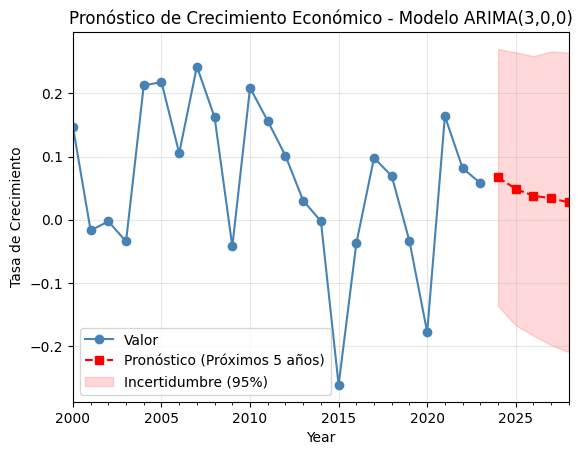

In [79]:
# 1. Crear el rango de años correctamente (evitando el error de Timestamp)
ultimo_anio = pib_crecimiento.index[-1]
# Creamos una lista de Timestamps para los próximos 5 años
anio_pronostico = [ultimo_anio + pd.DateOffset(years=i) for i in range(1, t_pronostico + 1)]

# 2. Obtener valores del pronóstico
pronostico_pib = mejormodelo.get_forecast(steps=t_pronostico)
pred_mean = pronostico_pib.predicted_mean
pred_ci = pronostico_pib.conf_int()

# 3. Asignar el nuevo índice de fechas
pred_mean.index = anio_pronostico
pred_ci.index = anio_pronostico

# 4. Graficar (limitando el histórico para que se vea mejor el detalle)
plt.figure(figsize=(12, 6))
# Graficamos desde el año 2000 para ver mejor el pronóstico
pib_crecimiento['2000':].plot(label="Histórico (Colombia)", color='steelblue', marker='o')
pred_mean.plot(label="Pronóstico (Próximos 5 años)", color='red', linestyle='--', marker='s')

# Rellenar intervalo de confianza (esto quita lo "raro" al mostrar la incertidumbre)
plt.fill_between(pred_ci.index, pred_ci.iloc[:, 0], pred_ci.iloc[:, 1], color='red', alpha=0.15, label="Incertidumbre (95%)")

plt.title("Pronóstico de Crecimiento Económico - Modelo ARIMA(3,0,0)")
plt.ylabel("Tasa de Crecimiento")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()